In [2]:
# Group Members


In [3]:
!pip install gymnasium ale-py

In [ ]:
#dqn helpers import, upload dqn zip
from google.colab import files
files.upload()

In [5]:
!unzip -o dqn.zip

Archive:  dqn.zip
   creating: dqn/
  inflating: dqn/agent.py            
  inflating: dqn/model.py            
  inflating: dqn/replay_buffer.py    
  inflating: dqn/wrappers.py         


In [6]:
import os
print(os.listdir())

['.config', 'dqn.zip', 'dqn', 'sample_data']


In [9]:
import random
import numpy as np
import gym
import torch
import gymnasium
import ale_py
gymnasium.register_envs(ale_py)

from dqn.agent import DQNAgent
from dqn.replay_buffer import ReplayBuffer
from dqn.wrappers import *

class MakeGymPong(gym.Env):


    def __init__(self):

        self._env = gymnasium.make("ALE/Pong-v5", frameskip=1, repeat_action_probability = 0.0)
        self.observation_space = gym.spaces.Box(0,255, self._env.observation_space.shape, np.uint8)
        self.action_space = gym.spaces.Discrete(self._env.action_space.n)
        self.ale = self._env.unwrapped.ale

    def get_action_meanings(self):
        return self._env.unwrapped.get_action_meanings()

    def seed(self, seed = None):
        self._env.reset(seed=seed)

    def reset(self, **kwargs):
        obs,_ = self._env.reset(**kwargs)
        return obs

    def step(self, action):
        obs, reward, terminated, truncated, info = self._env.step(action)
        return obs, reward, terminated or truncated, info




if __name__ == "__main__":

    hyper_params = {
        "seed": 42,  # which seed to use
        "env": "PongNoFrameskip-v4",  # name of the game
        "replay-buffer-size": int(5e3),  # replay buffer size
        "learning-rate": 1e-4,  # learning rate for Adam optimizer
        "discount-factor": 0.99,  # discount factor
        "num-steps": int(1e6),  # total number of steps to run the environment for
        "batch-size": 256,  # number of transitions to optimize at the same time
        "learning-starts": 10000,  # number of steps before learning starts
        "learning-freq": 5,  # number of iterations between every optimization step
        "use-double-dqn": True,  # use double deep Q-learning
        "target-update-freq": 1000,  # number of iterations between every target network update
        "eps-start": 1.0,  # e-greedy start threshold
        "eps-end": 0.01,  # e-greedy end threshold
        "eps-fraction": 0.1,  # fraction of num-steps
        "print-freq": 10,
    }

    np.random.seed(hyper_params["seed"])
    random.seed(hyper_params["seed"])

    assert "NoFrameskip" in hyper_params["env"], "Require environment with no frameskip"
    env = MakeGymPong()
    env.seed(hyper_params["seed"])

    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    env = EpisodicLifeEnv(env)
    env = FireResetEnv(env)
    # Pick Gym wrappers to use

    env = WarpFrame(env)
    #convert to pytorch
    env = PyTorchFrame(env)
    env = ClipRewardEnv(env)
    #last 4 frames
    env = FrameStack(env, 4)


    replay_buffer = ReplayBuffer(hyper_params["replay-buffer-size"])

    #  Create dqn agent

    agent = DQNAgent(
        env.observation_space,
        env.action_space,
        replay_buffer,
        use_double_dqn=hyper_params["use-double-dqn"],
        lr = hyper_params["learning-rate"],
        batch_size=hyper_params["batch-size"],
        gamma = hyper_params["discount-factor"],
    )

    losses = []



    eps_timesteps = hyper_params["eps-fraction"] * float(hyper_params["num-steps"])
    episode_rewards = [0.0]

    state = env.reset()
    for t in range(hyper_params["num-steps"]):
        fraction = min(1.0, float(t) / eps_timesteps)
        eps_threshold = hyper_params["eps-start"] + fraction * (
            hyper_params["eps-end"] - hyper_params["eps-start"]
        )
        sample = random.random()

        # select random action if sample is less equal than eps_threshold
        # take step in env
        # add state, action, reward, next_state, float(done) to reply memory - cast done to float
        # add reward to episode_reward

        if sample <= eps_threshold:
            action = env.action_space.sample()
        else:
            action = agent.act(state)

        next_state, reward, done, info = env.step(action)
        replay_buffer.add(state, action, reward, next_state, float(done))
        state = next_state

        episode_rewards[-1] += reward
        if done:
            state = env.reset()
            episode_rewards.append(0.0)

        if (
            t > hyper_params["learning-starts"]
            and t % hyper_params["learning-freq"] == 0
        ):
            loss = agent.optimise_td_loss()
            losses.append(loss)

        if (
            t > hyper_params["learning-starts"]
            and t % hyper_params["target-update-freq"] == 0
        ):
            agent.update_target_network()

        num_episodes = len(episode_rewards)

        if (
            done
            and hyper_params["print-freq"] is not None
            and len(episode_rewards) % hyper_params["print-freq"] == 0
        ):
            mean_100ep_reward = round(np.mean(episode_rewards[-101:-1]), 1)
            print("********************************************************")
            print("steps: {}".format(t))
            print("episodes: {}".format(num_episodes))
            print("mean 100 episode reward: {}".format(mean_100ep_reward))
            print("% time spent exploring: {}".format(int(100 * eps_threshold)))
            print("********************************************************")


    torch.save(agent.policy_network.state_dict(), "model.pt")

********************************************************
steps: 17592
episodes: 20
mean 100 episode reward: -20.2
% time spent exploring: 82
********************************************************
********************************************************
steps: 27146
episodes: 30
mean 100 episode reward: -20.0
% time spent exploring: 73
********************************************************
********************************************************
steps: 36023
episodes: 40
mean 100 episode reward: -20.1
% time spent exploring: 64
********************************************************
********************************************************
steps: 45063
episodes: 50
mean 100 episode reward: -20.1
% time spent exploring: 55
********************************************************
********************************************************
steps: 53771
episodes: 60
mean 100 episode reward: -20.3
% time spent exploring: 46
********************************************************
**********

In [10]:
print(len(losses), losses[-5:])
import os; print("model.pt" in os.listdir())

197999 [0.001029567327350378, 0.0012482391903176904, 0.0011361058568581939, 0.0017360911006107926, 0.0010534259490668774]
True


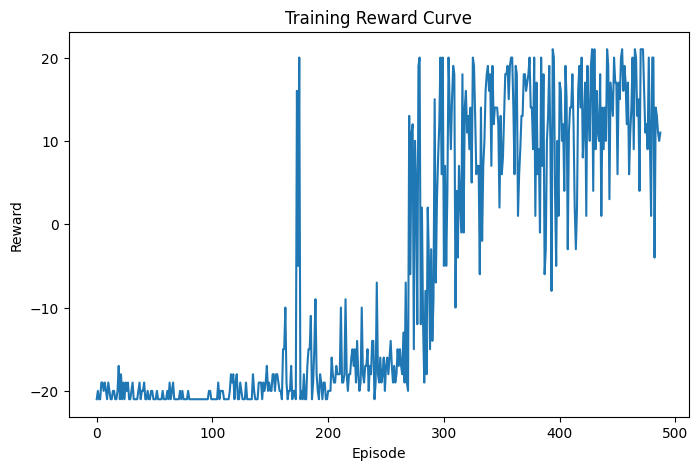

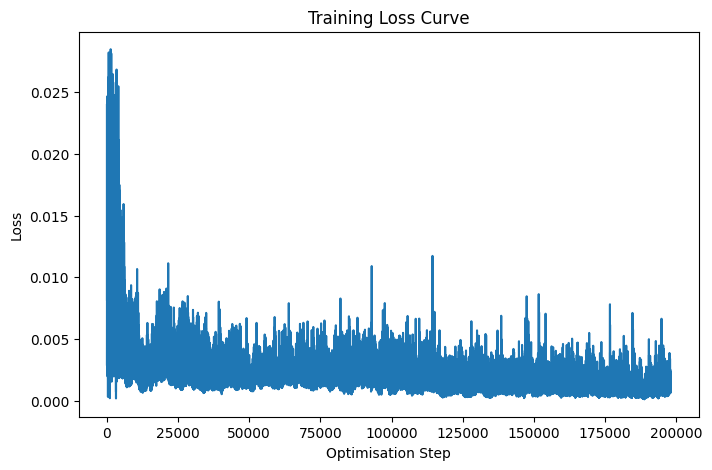

In [13]:
# plotting
import matplotlib.pyplot as plt


#store arrays
np.save("episode_rewards.npy", np.array(episode_rewards))
np.save("losses.npy", np.array(losses))

# reward curve
rewards = np.array(episode_rewards[:-1])

plt.figure(figsize=(8,5))
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward Curve")
plt.savefig("reward_curve.png",dpi = 150)
plt.show()

# loss curve
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Optimisation Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.savefig("loss_curve.png",dpi = 150)
plt.show()




In [14]:
# gif work
import imageio

frames = []
state = env.reset()
done = False
while not done:
  action = agent.act(state) if random.random() > 0.05 else env.action_space.sample()
  state, _, done, _ = env.step(action)
  frames.append(env.unwrapped.ale.getScreenRGB())

imageio.mimsave("trained_agent.gif",frames, fps=30)


/content/dqn/agent.py:113: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  state = torch.from_numpy(np.array(state)).unsqueeze(0).to(device)
/usr/local/lib/python3.13/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


In [16]:
#saving training data


for f in ["model.pt", "episode_rewards.npy", "losses.npy", "reward_curve.png","loss_curve.png","trained_agent.gif"]:
  files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>